In [1]:
import numpy as np
from itertools import chain
from pathlib import Path
from response_stats.generators import PoissonSpikeGenerator
from response_stats.responses import ResponseConfig, make_response_data, ResponseDetector
from response_stats.responses.response_tests import WilcoxonTest, SurrogateTest

from response_stats.plot_utils import *
from scipy.stats import beta

In [2]:
rng = np.random.default_rng(seed=73)

[1.09330591 0.77808783 0.38161031 ... 0.82603817 1.78333346 0.13278459]
[16.04412614 14.23600261 15.89956595 ... 15.53193948 14.65056899
 16.76931894]


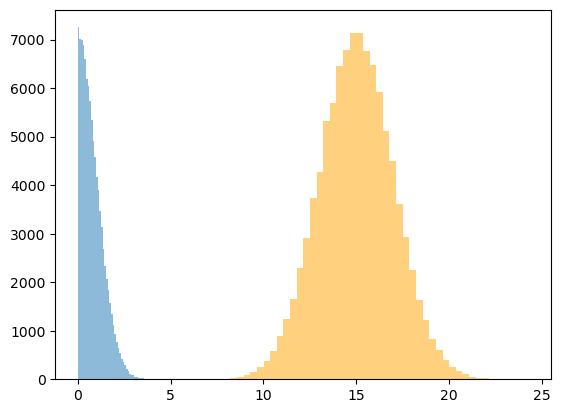

In [3]:
n_samples = 100_000

b   = 0
bs  = 1
r   = 15
rs  = 2

burst_rate_baseline = np.abs(rng.normal(b, bs, n_samples))
burst_rate_response = np.abs(rng.normal(r, rs, n_samples))
print(burst_rate_baseline)        
print(burst_rate_response)

plt.hist(burst_rate_baseline, alpha=0.5, bins=50)
plt.hist(burst_rate_response, alpha=0.5, color="orange", bins=50)
plt.show()

[0.17453111]
[16.30976171]


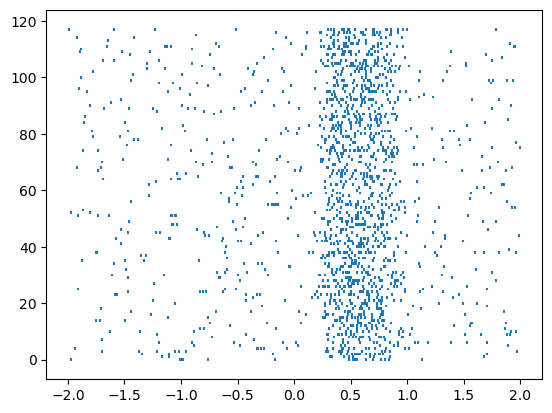

In [ ]:
baseline_fr=1

response_fr=20

latency=0.355
duration=0.687
baseline_T=2
stimulus_T=2
dt=0.001

induce_refractory_period=False


a=1.328
b=2.1

include_bursts=True

burst_response_time_factor=5
burst_duration_lam=100
burst_alpha=1.5
burst_beta=3
burst_multiplier=15

n_samples = 1

ba   = 0
bs  = 1
r   = 15
rs  = 2

burst_rate_baseline = np.abs(rng.normal(ba, bs, n_samples))
burst_rate_response = np.abs(rng.normal(r, rs, n_samples))
print(burst_rate_baseline)        
print(burst_rate_response)


n_trials = 118

generator = PoissonSpikeGenerator(
baseline_fr=baseline_fr,
response_fr=response_fr,
latency=latency,
duration=duration,
baseline_T=baseline_T,
stimulus_T=stimulus_T,
dt=dt,
induce_refractory_period=induce_refractory_period,
rng=rng,
a=a,
b=b,
include_bursts=include_bursts, 
burst_rate_baseline=burst_rate_baseline, 
burst_rate_response=burst_rate_response, 
burst_response_time_factor=burst_response_time_factor, 
burst_duration_lam=burst_duration_lam,
burst_alpha=burst_alpha, 6
burst_beta=burst_beta,
burst_multiplier=burst_multiplier,
)

# generate trials
trial_activity = generator.generate(n_trials)


# rescale
trial_activity = [t - baseline_T for t in trial_activity]    

plt.eventplot(trial_activity)
plt.show()

In [8]:
sum(np.concatenate([np.diff(t) for t in trial_activity]) <= 0.003)

np.int64(3)

In [ ]:

baseline_fr = 2
response_fr = 25
latency = 0.3
duration = 0.25
dt = 0.001
baseline_T = 1
stimulus_T = 1
a = 1.5
b = 3

total_bins = int((baseline_T + stimulus_T) / dt)

induce_refractory_period = True

n_trials = 8

generator = PoissonSpikeGenerator(
    baseline_fr=baseline_fr,
    response_fr=response_fr,
    latency=latency,
    duration=duration,
    baseline_T=baseline_T,
    stimulus_T=stimulus_T,
    dt=dt,
    induce_refractory_period=induce_refractory_period,
    a = a,
    b = b,
)

trial_activity = generator.generate(n_trials)

cfg_response_dict = {
    "trial_activity": trial_activity,
    "baseline_T": baseline_T,
    "stimulus_T": stimulus_T,
    "stimulus_onset": baseline_T,
    "bin_width": 0.1,
    "dt": dt,
    "direction": "positive",
    "proportion_active": 0,
    "multiple_correction": "simes",
    "interleave_response_bins": True,
    "smooth_response_bins": False,
    "debug": True,
}


In [ ]:
n = 100_000

br_r = abs(generator.rng.normal(15, 2, n))
br_b = abs(generator.rng.normal(0, 1, n))

plt.hist(br_r, bins=100, alpha=0.5, density=True, label="burst_rate, response")
plt.hist(br_b, bins=100, alpha=0.5, density=True, label="burst_rate, baseline")

plt.title("burst rates for baseline/response periods\nparameters for n_bursts ~ Poisson(u)")
plt.xlabel("avg. burst rate values [Hz]")
plt.ylabel("probability")
plt.legend()

sns.despine()
plt.show()

In [ ]:
burst_duration = np.array(generator.rng.normal(200, lam_burst_duration/4, size=100_000), dtype=int) # ms
plt.hist(burst_duration)

In [ ]:
def generate_bursts(r_t, T_on, T_off, avg_burst_rate, 
                    burst_multiplier, burst_alpha, burst_beta,
                    lam_burst_duration
                    ):

    segment_len = T_off - T_on
    n_bursts = generator.rng.poisson(lam=avg_burst_rate * segment_len, size=1)[0]
    burst_onsets = np.sort(generator.rng.uniform(low=T_on, high=T_off, size=n_bursts))
    burst_onsets_ms = np.array(burst_onsets / dt, dtype=int)

    burst_duration = np.array(generator.rng.poisson(lam_burst_duration, size=n_bursts), dtype=int) # ms
    
    for b in range(n_bursts):
        x_ = np.linspace(0, 1, burst_duration[b])
        r_ = beta.pdf(x_, burst_alpha, burst_beta)
        r_r = r_ * burst_multiplier + baseline_fr

        end_burst = np.min([burst_onsets_ms[b]+burst_duration[b], (T_off / dt)],)
        end_burst = int(end_burst)
        burst_len = end_burst - burst_onsets_ms[b]

        r_t[burst_onsets_ms[b]: end_burst] = r_r[:burst_len]
    
    return r_t


n_trials = 100

# generate this once for a cell/response
baseline_burst_rate = abs(generator.rng.normal(0, 1, 1))
response_burst_rate = abs(generator.rng.normal(15, 2, 1))

response_time_buffer = generator.duration / 5
print(response_time_buffer)

burst_alpha = 1.5
burst_beta  = 3
burst_multiplier = 15

lam_burst_duration = 150

trials: list[np.ndarray] = []
rate_fxns = np.ones((n_trials, len(generator.r_t)))
n_bursts_total: list[np.ndarray] = []
for i in range(n_trials):

    r_t = generator.r_t.copy()

    trial_burst_count = 0

    T_on = 0
    T_off = (generator.response_onset * dt) - response_time_buffer
    r_t, n_bursts = generate_bursts(r_t, T_on, T_off, baseline_burst_rate, 
                    burst_multiplier, burst_alpha, burst_beta,
                    lam_burst_duration)
    
    trial_burst_count += n_bursts

    T_on = generator.response_offset * dt
    T_off = (generator.baseline_T + generator.stimulus_T)
    r_t, n_bursts = generate_bursts(r_t, T_on, T_off, baseline_burst_rate, 
                    burst_multiplier, burst_alpha, burst_beta,
                    lam_burst_duration)
    trial_burst_count += n_bursts

    T_on = (generator.response_onset * dt) - response_time_buffer
    T_off = (generator.response_offset * dt) - (generator.duration / 2)
    r_t, n_bursts = generate_bursts(r_t, T_on, T_off, response_burst_rate, 
                    burst_multiplier, burst_alpha, burst_beta,
                    lam_burst_duration)
    trial_burst_count += n_bursts

    n_bursts_total.append(trial_burst_count)
    rate_fxns[i,:] = r_t

    p = r_t * dt 
    hits = generator.rng.random(size=(n_trials, total_bins)) <= p
    idx = np.flatnonzero(hits[i])
    spike_times = idx.astype(float) * dt

    # remove the "right-hand" spikes corresponding to the 10th percentile of the ISIs
    isis = np.diff(spike_times)
    if len(isis) > 1:
        perc_val = np.percentile(isis, 10, axis=0)

        inds = np.where(isis <= perc_val)[0]

        bad_spikes = inds + 1
        spike_times = np.delete(spike_times, bad_spikes)


    trials.append(spike_times)



isis = np.concatenate([np.diff(t) for t in trials], dtype=np.float64)
isis_v = (sum(isis < 0.003) / len(isis)) * 100



title_text = [
    "bursty psth",
    f"FR_b: {baseline_fr}    FR_r: {response_fr}",
    f"burst_rates, params [Hz] - b: {round(baseline_burst_rate[0], 3)}   r: {round(response_burst_rate[0], 3)}",
    f"avg. bursts / trials: {np.mean(n_bursts_total)}",
    f"ISIs < 3 ms: {round(isis_v, 3)}%"
]



fig, ax = plt.subplots(1,1, figsize=(8,5))
ax.eventplot(trials)
ax.vlines(1, -1, n_trials, color="orange")

ax.set_title("\n".join(title_text))

ax.set_xlabel("time [s]")
ax.set_ylabel("trial index")
sns.despine(left=True)

plt.show()

In [ ]:

def response_curve(b, slope, offset):
    return b * slope + offset

baseline_fr = 4
response_fr = response_curve(baseline_fr, 2, 5)
#response_fr = response_curve(baseline_fr, 2, 10) 
latency = 0.3
duration = 0.7
dt = 0.001
baseline_T = 1
stimulus_T = 1
a = 1.5
b = 3

total_bins = int((baseline_T + stimulus_T) / dt)

induce_refractory_period = True

n_trials = 8

generator = PoissonSpikeGenerator(
    baseline_fr=baseline_fr,
    response_fr=response_fr,
    latency=latency,
    duration=duration,
    baseline_T=baseline_T,
    stimulus_T=stimulus_T,
    dt=dt,
    induce_refractory_period=induce_refractory_period,
    a = a,
    b = b,
)

trial_activity = generator.generate(n_trials)

cfg_response_dict = {
    "trial_activity": trial_activity,
    "baseline_T": baseline_T,
    "stimulus_T": stimulus_T,
    "stimulus_onset": baseline_T,
    "bin_width": 0.1,
    "dt": dt,
    "direction": "positive",
    "proportion_active": 0,
    "multiple_correction": "simes",
    "interleave_response_bins": True,
    "smooth_response_bins": False,
    "debug": True,
}

cfg_response = ResponseConfig(**cfg_response_dict)
data_response = make_response_data(cfg_response)

detector = ResponseDetector(data_response, WilcoxonTest)
print(round(detector.compute_min_pval(),5))
fig, ax = SpikeSummaryFigure(trial_activity, generator, detector, ).build()

fig.savefig(f"plots/{baseline_fr}_{response_fr}.jpg")

In [ ]:
res = {}
FRs = np.arange(0.5, 10, 0.25)
trial_list = [20, 30, 40, 50, 60, 70, 80, 85, 90, 100]

for fr in FRs:
    baseline_fr = fr
    response_fr = fr
    latency = 0.3
    duration = 0.7
    dt = 0.001
    baseline_T = 1
    stimulus_T = 1
    a = 1.5
    b = 3

    total_bins = int((baseline_T + stimulus_T) / dt)

    induce_refractory_period = True

    pval_collection = []

    for n_trials in trial_list:
        

        generator = PoissonSpikeGenerator(
            baseline_fr=baseline_fr,
            response_fr=response_fr,
            latency=latency,
            duration=duration,
            baseline_T=baseline_T,
            stimulus_T=stimulus_T,
            dt=dt,
            induce_refractory_period=induce_refractory_period,
            a = a,
            b = b,
        )

        trial_activity = generator.generate(n_trials)

        cfg_response_dict = {
            "trial_activity": trial_activity,
            "baseline_T": baseline_T,
            "stimulus_T": stimulus_T,
            "stimulus_onset": baseline_T,
            "bin_width": 0.1,
            "dt": dt,
            "direction": "positive",
            "proportion_active": 1/3,
            "multiple_correction": "simes",
            "interleave_response_bins": True,
            "smooth_response_bins": False,
            "debug": True,
        }

        cfg_response = ResponseConfig(**cfg_response_dict)
        data_response = make_response_data(cfg_response)

        detector = ResponseDetector(data_response, WilcoxonTest)
        print(round(detector.compute_min_pval(),5))
        pval_collection.append(detector.compute_min_pval())
    res[fr] = pval_collection

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = sns.color_palette("viridis", n_colors=len(res))

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

for color, fr in zip(palette, res.keys()):
    y = res[fr]
    ax.plot(trial_list, y, color=color, label=fr)
fig.legend()
plt.show()

In [ ]:
baseline_fr = 0.5

e = 3
gain_high = 50
b = (gain_high - e) 
y = 3
x = baseline_fr

gain = (1/y)**x * b  + e
response_fr = round(baseline_fr * gain,3)

latency = 0.3
duration = 0.5
dt = 0.001
baseline_T = 1
stimulus_T = 1
a = 1.
b = 1.75

total_bins = int((baseline_T + stimulus_T) / dt)

induce_refractory_period = True

n_trials = 10

generator = PoissonSpikeGenerator(
    baseline_fr=baseline_fr,
    response_fr=response_fr,
    latency=latency,
    duration=duration,
    baseline_T=baseline_T,
    stimulus_T=stimulus_T,
    dt=dt,
    induce_refractory_period=induce_refractory_period,
    a = a,
    b = b,
)

trial_activity = generator.generate(n_trials)

cfg_response_dict = {
    "trial_activity": trial_activity,
    "baseline_T": baseline_T,
    "stimulus_T": stimulus_T,
    "stimulus_onset": baseline_T,
    "bin_width": 0.1,
    "dt": dt,
    "direction": "positive",
    "proportion_active": 1/3,
    "multiple_correction": "simes",
    "interleave_response_bins": True,
    "smooth_response_bins": False,
    "debug": True,
}

cfg_response = ResponseConfig(**cfg_response_dict)
data_response = make_response_data(cfg_response)


detector = ResponseDetector(data_response, WilcoxonTest)

SpikeSummaryFigure(trial_activity, generator, detector, ).build()